# GumbelRIS with Mutual Coupling (MC-Aware)

This notebook extends the original GumbelRIS implementation to incorporate **mutual coupling (MC)** effects among RIS elements.

## Key Change: The RIS Response Matrix

**Without MC (original):**
$$C = G \Phi H + D, \quad \Phi = \text{diag}(\phi)$$

**With MC (this notebook):**
$$C = G (\Gamma^{-1} - S)^{-1} H + D, \quad \Gamma = \text{diag}(\gamma)$$

where $S \in \mathbb{C}^{N_{RIS} \times N_{RIS}}$ is the **scattering matrix** encoding mutual coupling between RIS elements, derived from the mutual impedance Z-matrix:
$$S = (Z + Z_0 I)^{-1}(Z - Z_0 I)$$

The mutual impedance $Z_{qp}$ between elements $q$ and $p$ is computed via the double integral (Eq. 2 from the referenced paper):
$$Z_{qp} = \frac{j\eta_0}{4\pi k_0} \int_{-h_q}^{h_q} \int_{-h_p}^{h_p} \frac{e^{-jk_0 R(\xi,z)} \sin(k_0(h_p-|\xi|))\sin(k_0(h_q-|z|))}{R(\xi,z)\sin(k_0 h_p)\sin(k_0 h_q)} \left( k_0^2 - \frac{jk_0}{R} - \frac{k_0^2(z-\xi+\rho_2)^2+1}{R^2} + \frac{3jk_0(z-\xi+\rho_2)^2}{R^3} + \frac{3(z-\xi+\rho_2)^2}{R^4} \right) d\xi\, dz$$

where $R(\xi,z) = \sqrt{\rho_2^2 + (z-\xi)^2}$ and $\rho_2$ is the inter-element separation distance.

**Reference:** Zheng et al., "Mutual Coupling-Aware Channel Estimation and Beamforming for RIS-Assisted Communications," IEEE TWC, 2026.

In [1]:
import matplotlib.pyplot as plt
from google.colab import drive
import time
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/RIS_Channels.mat'

Mounted at /content/drive


In [2]:
!pip install scipy

import numpy as np
import scipy.io as sio
import scipy.integrate as integrate
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import math
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Mutual Coupling: Z-Matrix and S-Matrix Computation

We model each RIS element as a thin cylindrical dipole wire. The mutual impedance $Z_{qp}$ between any two elements is computed analytically using the integral formula from the paper. The S-matrix is then derived from the Z-matrix.

In [4]:
# ============================================================
# MUTUAL COUPLING: IMPEDANCE INTEGRAL (Eq. 2 from paper image)
# ============================================================
#
# Physical parameters (consistent with Zheng et al. Table / Sec VII-A):
#   eta0 = 377 Ohm  (intrinsic impedance of free space)
#   k0   = 2*pi/lambda  (free-space wavenumber)
#   h    = lambda/32    (half-length of each dipole wire)
#   r    = lambda/500   (wire radius, used only for self-impedance)
#   Z0   = 50 Ohm       (characteristic impedance for S-param conversion)
#
# The integral computes Z_qp between element q (field) and element p (source)
# separated by distance rho2 in the plane of the RIS.
# R(xi, z) = sqrt(rho2^2 + (z - xi)^2)  -- 3D distance between
#             source current element at xi along wire p
#             and field observation point at z along wire q

def compute_mutual_impedance(rho2, k0, h, eta0=377.0):
    """
    Compute the mutual impedance Z_qp between two parallel dipole wires
    separated by transverse distance rho2.

    Uses the double integral from Eq. (2) of the referenced paper:

        Z_qp = j*eta0/(4*pi*k0) * INT INT [
            e^{-jk0*R} * sin(k0*(h-|xi|)) * sin(k0*(h-|z|))
            / (R * sin(k0*h)^2)
            * (k0^2 - jk0/R - (k0^2*(z-xi)^2 + 1)/R^2
               + 3*jk0*(z-xi)^2/R^3 + 3*(z-xi)^2/R^4)
        ] d_xi dz

    where R = sqrt(rho2^2 + (z - xi)^2).

    Note: The (z - xi + rho2) terms in the original integral reduce to
    (z - xi) in the distance-component when rho2 is the transverse
    (perpendicular) separation. For a UPA, rho2 = ||pos_q - pos_p||.

    Parameters
    ----------
    rho2  : float  - separation distance between the two wire centres (metres)
    k0    : float  - free-space wavenumber 2*pi/lambda
    h     : float  - half-length of each dipole  (lambda/32)
    eta0  : float  - intrinsic impedance of free space (377 Ohm)

    Returns
    -------
    Z_qp  : complex  (Ohms)
    """
    sin_k0h = np.sin(k0 * h)
    prefactor = 1j * eta0 / (4 * np.pi * k0)

    def integrand_real(xi, z):
        dz = z - xi
        R = np.sqrt(rho2**2 + dz**2)
        if R < 1e-15:
            return 0.0
        phase = np.exp(-1j * k0 * R)
        shape = (np.sin(k0 * (h - abs(xi))) *
                 np.sin(k0 * (h - abs(z)))) / (R * sin_k0h**2)
        kernel = (k0**2
                  - 1j * k0 / R
                  - (k0**2 * dz**2 + 1.0) / R**2
                  + 3j * k0 * dz**2 / R**3
                  + 3.0 * dz**2 / R**4)
        val = phase * shape * kernel
        return np.real(val)

    def integrand_imag(xi, z):
        dz = z - xi
        R = np.sqrt(rho2**2 + dz**2)
        if R < 1e-15:
            return 0.0
        phase = np.exp(-1j * k0 * R)
        shape = (np.sin(k0 * (h - abs(xi))) *
                 np.sin(k0 * (h - abs(z)))) / (R * sin_k0h**2)
        kernel = (k0**2
                  - 1j * k0 / R
                  - (k0**2 * dz**2 + 1.0) / R**2
                  + 3j * k0 * dz**2 / R**3
                  + 3.0 * dz**2 / R**4)
        val = phase * shape * kernel
        return np.imag(val)

    # Numerical double integration over [-h, h] x [-h, h]
    real_part, _ = integrate.dblquad(
        integrand_real, -h, h, lambda xi: -h, lambda xi: h,
        epsabs=1e-6, epsrel=1e-6
    )
    imag_part, _ = integrate.dblquad(
        integrand_imag, -h, h, lambda xi: -h, lambda xi: h,
        epsabs=1e-6, epsrel=1e-6
    )

    return prefactor * (real_part + 1j * imag_part)


def compute_self_impedance(k0, h, r, eta0=377.0):
    """
    Compute the self-impedance Z_qq of a thin cylindrical dipole wire.
    Uses the same integral formula with rho2 replaced by the wire radius r.
    This is the diagonal entry of the Z-matrix.
    """
    return compute_mutual_impedance(r, k0, h, eta0)


def build_z_matrix(N_ris, d_element, freq, eta0=377.0, Z0=50.0,
                   h_factor=1/32, r_factor=1/500,
                   array_type='UPA'):
    """
    Build the full N_ris x N_ris mutual impedance matrix Z for a RIS.

    Parameters
    ----------
    N_ris      : int    - number of RIS elements
    d_element  : float  - inter-element spacing (metres)
    freq       : float  - carrier frequency (Hz)
    eta0       : float  - free-space impedance (377 Ohm)
    Z0         : float  - characteristic impedance for S-param (50 Ohm)
    h_factor   : float  - half-length = h_factor * lambda
    r_factor   : float  - wire radius  = r_factor * lambda
    array_type : str    - 'UPA' (square) or 'ULA'

    Returns
    -------
    Z : ndarray (N_ris, N_ris) complex  - impedance matrix
    S : ndarray (N_ris, N_ris) complex  - scattering matrix
    """
    lam = 3e8 / freq           # wavelength
    k0  = 2 * np.pi / lam     # wavenumber
    h   = h_factor * lam      # dipole half-length
    r   = r_factor * lam      # wire radius

    print(f"  lambda={lam:.4f}m, k0={k0:.2f}, h={h:.5f}m, d={d_element:.4f}m")

    # Build element positions for UPA (square array) or ULA
    if array_type == 'UPA':
        n_side = int(np.round(np.sqrt(N_ris)))
        assert n_side * n_side == N_ris, \
            f"For UPA, N_ris must be a perfect square. Got {N_ris}."
        # 2D grid positions
        idx = np.arange(n_side)
        xx, yy = np.meshgrid(idx * d_element, idx * d_element)
        pos = np.stack([xx.flatten(), yy.flatten()], axis=1)  # (N,2)
    else:  # ULA
        pos = np.column_stack([np.arange(N_ris) * d_element,
                               np.zeros(N_ris)])  # (N,2)

    # Compute Z-matrix
    Z = np.zeros((N_ris, N_ris), dtype=complex)
    self_imp = compute_self_impedance(k0, h, r, eta0)

    print(f"  Self-impedance Z_qq = {self_imp:.4f} Ohm")

    # Cache: symmetric matrix, only compute upper triangle
    cache = {}
    total_pairs = N_ris * (N_ris - 1) // 2
    computed = 0

    for q in range(N_ris):
        Z[q, q] = self_imp
        for p in range(q + 1, N_ris):
            rho2 = np.linalg.norm(pos[q] - pos[p])  # 2D separation
            # Round to avoid recomputing nearly-identical separations
            rho2_key = round(rho2 / (lam * 1e-4)) * (lam * 1e-4)
            if rho2_key not in cache:
                cache[rho2_key] = compute_mutual_impedance(rho2, k0, h, eta0)
                computed += 1
                if computed % 5 == 0:
                    print(f"  Computed {computed} unique separations...")
            Z[q, p] = cache[rho2_key]
            Z[p, q] = cache[rho2_key]  # Symmetry: Z_qp = Z_pq

    # Convert Z to S-parameters: S = (Z + Z0*I)^{-1} (Z - Z0*I)
    I = np.eye(N_ris)
    S = np.linalg.solve(Z + Z0 * I, Z - Z0 * I)

    return Z, S


print("Mutual coupling functions defined.")

Mutual coupling functions defined.


## Precompute the Scattering Matrix S

We compute S **once** for the chosen RIS configuration and reuse it throughout training and inference. This is valid because S depends only on the array geometry (element positions and frequency), not on the channel realizations.

SimRIS parameters from the GumbelRIS paper: 28 GHz mmWave, indoor office, 256-element RIS.

In [5]:
# ============================================================
# SIMRIS-ALIGNED PHYSICAL PARAMETERS
# ============================================================
# From GumbelRIS paper Table I / SimRIS setup
FREQ       = 28e9          # 28 GHz mmWave carrier
LAM        = 3e8 / FREQ   # ~0.0107 m
N_RIS      = 256           # number of RIS elements (16x16 UPA)

# Inter-element spacing: SimRIS default is lambda/2
# To study MC strength, you can change this (e.g., lambda/10 gives strong MC)
D_ELEMENT  = LAM / 2      # lambda/2 spacing (default, weak MC)
# D_ELEMENT = LAM / 10    # lambda/10 spacing (strong MC)

print(f"Frequency: {FREQ/1e9:.1f} GHz")
print(f"Wavelength: {LAM*1000:.2f} mm")
print(f"Element spacing: {D_ELEMENT*1000:.2f} mm ({D_ELEMENT/LAM:.2f} lambda)")
print(f"N_RIS: {N_RIS} ({int(N_RIS**0.5)}x{int(N_RIS**0.5)} UPA)")
print()
print("Computing scattering matrix S (this may take a few minutes for N_RIS=256)...")
print("Tip: For quick testing, reduce N_RIS to 16 or 64 first.")

Frequency: 28.0 GHz
Wavelength: 10.71 mm
Element spacing: 5.36 mm (0.50 lambda)
N_RIS: 256 (16x16 UPA)

Computing scattering matrix S (this may take a few minutes for N_RIS=256)...
Tip: For quick testing, reduce N_RIS to 16 or 64 first.


In [6]:
# ---- Build S matrix ----
# For N_RIS=256 (16x16), there are 256*255/2 = 32640 pairs, but many share
# the same separation distance so the cache makes this tractable.
# Expected unique separations for 16x16 UPA: ~100-200 distinct rho2 values.

Z_matrix, S_matrix = build_z_matrix(
    N_ris      = N_RIS,
    d_element  = D_ELEMENT,
    freq       = FREQ,
    array_type = 'UPA'
)

print(f"\nZ matrix shape: {Z_matrix.shape}")
print(f"S matrix shape: {S_matrix.shape}")
print(f"||S|| (Frobenius): {np.linalg.norm(S_matrix):.4f}")
print(f"Max |S_ij|: {np.max(np.abs(S_matrix)):.4f}")
print(f"Diagonal |S_ii| mean: {np.mean(np.abs(np.diag(S_matrix))):.4f}")
print(f"Off-diagonal |S_ij| mean: {np.mean(np.abs(S_matrix - np.diag(np.diag(S_matrix)))):.6f}")

# Convert to PyTorch tensor (kept on CPU, moved to device in loss function)
S_tensor = torch.tensor(S_matrix, dtype=torch.complex64)

  lambda=0.0107m, k0=586.43, h=0.00033m, d=0.0054m
  Self-impedance Z_qq = 0.7750-1109.2910j Ohm
  Computed 5 unique separations...
  Computed 10 unique separations...
  Computed 15 unique separations...
  Computed 20 unique separations...
  Computed 25 unique separations...
  Computed 30 unique separations...
  Computed 35 unique separations...
  Computed 40 unique separations...
  Computed 45 unique separations...
  Computed 50 unique separations...
  Computed 55 unique separations...
  Computed 60 unique separations...
  Computed 65 unique separations...
  Computed 70 unique separations...
  Computed 75 unique separations...
  Computed 80 unique separations...
  Computed 85 unique separations...
  Computed 90 unique separations...
  Computed 95 unique separations...
  Computed 100 unique separations...
  Computed 105 unique separations...
  Computed 110 unique separations...
  Computed 115 unique separations...

Z matrix shape: (256, 256)
S matrix shape: (256, 256)
||S|| (Frobenius)

## Data Loading (unchanged from original GumbelRIS)

In [7]:
from scipy.io import loadmat
data = loadmat(DATA_PATH)

print(data.keys())
G_all = data['G']
H_all = data['H']
D_all = data['D']

print("Shapes:")
print("G:", G_all.shape)
print("H:", H_all.shape)
print("D:", D_all.shape)

dict_keys(['__header__', '__version__', '__globals__', 'H', 'G', 'D'])
Shapes:
G: (64, 256, 5000)
H: (256, 64, 5000)
D: (64, 64, 5000)


In [8]:
class RISDataset(Dataset):
    def __init__(self, G, H, D):
        self.G = G
        self.H = H
        self.D = D
        self.N = G.shape[2]

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        G = self.G[:, :, idx]      # (64, 256)
        H = self.H[:, :, idx]      # (256, 64)
        D = self.D[:, :, idx]      # (64, 64)

        power = (
            np.mean(np.abs(G)**2) +
            np.mean(np.abs(H)**2) +
            np.mean(np.abs(D)**2)
        )
        scale = np.sqrt(power + 1e-12)

        G_scaled = G / scale
        H_scaled = H / scale
        D_scaled = D / scale

        H_pad = H_scaled.T
        D_pad = np.zeros((64, 256), dtype=np.complex128)
        D_pad[:, :64] = D_scaled

        tensor = np.stack([
            np.real(G_scaled), np.imag(G_scaled),
            np.real(H_pad),    np.imag(H_pad),
            np.real(D_pad),    np.imag(D_pad)
        ], axis=0)  # (6, 64, 256)

        return (
            torch.tensor(tensor, dtype=torch.float32),
            torch.tensor(G, dtype=torch.complex64),
            torch.tensor(H, dtype=torch.complex64),
            torch.tensor(D, dtype=torch.complex64)
        )

In [9]:
dataset = RISDataset(G_all, H_all, D_all)

N = len(dataset)
train_size = int(0.6 * N)
val_size   = int(0.2 * N)
test_size  = N - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8)
test_loader  = DataLoader(test_set,  batch_size=8)

print("Split done:", train_size, val_size, test_size)

Split done: 3000 1000 1000


## GumbelRIS Model (unchanged architecture)

In [10]:
class GumbelRIS(nn.Module):
    def __init__(self, tau=1.0):
        super().__init__()
        self.tau = tau
        self.conv = nn.Conv2d(6, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(32, 256 * 4)

    def forward(self, x, hard=False):
        x = F.relu(self.conv(x))
        x = self.pool(x).view(x.size(0), -1)
        logits = self.fc(x).view(-1, 256, 4)
        y = F.gumbel_softmax(logits, tau=self.tau, hard=hard)
        return y, logits

In [11]:
theta = torch.tensor([0, math.pi/2, math.pi, 3*math.pi/2],
                     dtype=torch.float32, device=device)

def construct_phase(y):
    """
    Convert soft Gumbel-Softmax weights -> complex phase vector gamma.
    gamma_i = exp(j * phi_i),  phi_i in {0, pi/2, pi, 3pi/2}
    """
    phi = torch.sum(y * theta, dim=2)          # (batch, 256) real angles
    return torch.exp(1j * phi.to(torch.float32))  # (batch, 256) complex

## MC-Aware Capacity Loss

The **only** change from the original `compute_capacity` is how the effective channel `C` is formed:

- **Original:** `C = G @ diag(phi) @ H + D`
- **MC-Aware:** `C = G @ inv(inv(Gamma) - S) @ H + D`

where `Gamma = diag(gamma)` (complex RIS reflection coefficients) and `S` is the precomputed scattering matrix.

In [12]:
def compute_capacity_mc(G, H, D, gamma, S_mat, snr_db=20.0):
    """
    MC-Aware capacity computation.

    Parameters
    ----------
    G     : (batch, Nr, N_RIS)  complex tensor - RIS-to-UE channel
    H     : (batch, N_RIS, Nt)  complex tensor - BS-to-RIS channel
    D     : (batch, Nr, Nt)     complex tensor - direct BS-to-UE channel
    gamma : (batch, N_RIS)      complex tensor - RIS reflection coefficients
    S_mat : (N_RIS, N_RIS)      complex tensor - scattering matrix (precomputed)
    snr_db: float               - operating SNR in dB

    Returns
    -------
    mean capacity (scalar) over the batch

    Key formula (Zheng et al. Eq. 7):
        Phi_MC = (Gamma^{-1} - S)^{-1}
        C      = G @ Phi_MC @ H + D
    """
    batch = G.shape[0]
    snr_linear = 10.0 ** (snr_db / 10.0)
    S = S_mat.to(G.device)  # move S to same device as channels
    capacities = []

    for b in range(batch):
        # --- Build Gamma = diag(gamma_b) ---
        # gamma[b] shape: (N_RIS,)  complex
        Gamma = torch.diag(gamma[b])  # (N_RIS, N_RIS)

        # --- Compute Gamma^{-1} ---
        # Since Gamma is diagonal: Gamma^{-1} = diag(1/gamma)
        Gamma_inv = torch.diag(1.0 / gamma[b])  # (N_RIS, N_RIS)

        # --- MC-Aware RIS response: Phi_MC = (Gamma^{-1} - S)^{-1} ---
        # This is the FULL non-diagonal matrix (unlike the original diagonal diag(phi))
        A = Gamma_inv - S                          # (N_RIS, N_RIS)
        Phi_MC = torch.linalg.inv(A)               # (N_RIS, N_RIS)

        # --- Effective channel ---
        # C = G @ Phi_MC @ H + D
        C = G[b] @ Phi_MC @ H[b] + D[b]           # (Nr, Nt)

        # --- Normalize to make SNR meaningful (same as original) ---
        pwr = (C.abs() ** 2).mean()
        C   = C / (torch.sqrt(pwr) + 1e-12)

        # --- Capacity: log2 det(I + SNR * C^H C) ---
        Nr  = C.shape[0]
        I   = torch.eye(Nr, dtype=torch.complex64, device=G.device)
        M   = I + snr_linear * (C.conj().T @ C)

        sign, logdet = torch.linalg.slogdet(M)
        cap = logdet / torch.log(torch.tensor(2.0, device=G.device))
        capacities.append(cap.real)

    return torch.mean(torch.stack(capacities))


# Also keep the original (no MC) for comparison
def compute_capacity_no_mc(G, H, D, phi, snr_db=20.0):
    """
    Original diagonal-Phi capacity (no mutual coupling). Kept for comparison.
    """
    batch = G.shape[0]
    snr_linear = 10.0 ** (snr_db / 10.0)
    capacities = []

    for b in range(batch):
        Phi = torch.diag(phi[b])
        C   = G[b] @ Phi @ H[b] + D[b]
        pwr = (C.abs() ** 2).mean()
        C   = C / (torch.sqrt(pwr) + 1e-12)
        Nr  = C.shape[0]
        I   = torch.eye(Nr, dtype=torch.complex64, device=G.device)
        M   = I + snr_linear * (C.conj().T @ C)
        sign, logdet = torch.linalg.slogdet(M)
        cap = logdet / torch.log(torch.tensor(2.0, device=G.device))
        capacities.append(cap.real)

    return torch.mean(torch.stack(capacities))


print("Capacity functions defined (MC-aware and baseline).")

Capacity functions defined (MC-aware and baseline).


## Training: MC-Aware GumbelRIS

In [13]:
model = GumbelRIS(tau=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Total parameters:", sum(p.numel() for p in model.parameters()))

Total parameters: 35552


In [14]:
epochs      = 20
tau0        = 0.3
tau_min     = 0.1
anneal_rate = 0.95
train_losses = []

for epoch in range(epochs):
    model.train()
    model.tau = max(tau_min, tau0 * (anneal_rate ** epoch))
    total_loss = 0

    for x, G, H, D in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        y, _ = model(x)
        gamma = construct_phase(y)   # complex phase vector

        # ---- MC-AWARE LOSS ----
        # Pass gamma (not phi) and the scattering matrix S_tensor
        loss = -compute_capacity_mc(G, H, D, gamma, S_tensor, snr_db=20.0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Tau: {model.tau:.4f}")

Epoch 1: 100%|██████████| 375/375 [00:21<00:00, 17.31it/s]


Epoch  1 | Loss: -89.2506 | Tau: 0.3000


Epoch 2: 100%|██████████| 375/375 [00:14<00:00, 26.76it/s]


Epoch  2 | Loss: -89.2914 | Tau: 0.2850


Epoch 3: 100%|██████████| 375/375 [00:14<00:00, 26.18it/s]


...

Epoch 18 | Loss: -94.1964 | Tau: 0.1254


Epoch 19: 100%|██████████| 375/375 [00:14<00:00, 26.69it/s]


Epoch 19 | Loss: -95.0440 | Tau: 0.1192


Epoch 20: 100%|██████████| 375/375 [00:14<00:00, 26.67it/s]

Epoch 20 | Loss: -93.9092 | Tau: 0.1132


## Evaluation: MC-Aware vs No-MC (Side-by-Side)

In [15]:
import scipy.stats as stats

model.eval()
caps_mc     = []
caps_no_mc  = []

with torch.no_grad():
    for x, G, H, D in test_loader:
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        # Hard discrete inference (arg-max)
        y, _ = model(x, hard=True)
        gamma = construct_phase(y)

        # MC-aware evaluation
        cap_mc = compute_capacity_mc(G, H, D, gamma, S_tensor, snr_db=20.0)
        caps_mc.append(cap_mc.item())

        # No-MC evaluation (same phases, but ignoring S)
        cap_nmc = compute_capacity_no_mc(G, H, D, gamma, snr_db=20.0)
        caps_no_mc.append(cap_nmc.item())

mean_mc   = np.mean(caps_mc)
mean_nmc  = np.mean(caps_no_mc)
std_mc    = np.std(caps_mc)
std_nmc   = np.std(caps_no_mc)

ci_mc  = stats.t.interval(0.95, len(caps_mc)-1,
                           loc=mean_mc,  scale=std_mc/np.sqrt(len(caps_mc)))
ci_nmc = stats.t.interval(0.95, len(caps_no_mc)-1,
                           loc=mean_nmc, scale=std_nmc/np.sqrt(len(caps_no_mc)))

print("=" * 55)
print(f"{'Metric':<30} {'MC-Aware':>12} {'No-MC':>12}")
print("-" * 55)
print(f"{'Mean Capacity (bps/Hz)':<30} {mean_mc:>12.3f} {mean_nmc:>12.3f}")
print(f"{'Std Dev':<30} {std_mc:>12.3f} {std_nmc:>12.3f}")
print(f"{'95% CI lower':<30} {ci_mc[0]:>12.3f} {ci_nmc[0]:>12.3f}")
print(f"{'95% CI upper':<30} {ci_mc[1]:>12.3f} {ci_nmc[1]:>12.3f}")
print("=" * 55)

Metric                             MC-Aware        No-MC
-------------------------------------------------------
Mean Capacity (bps/Hz)              103.682      102.803
Std Dev                              16.735       17.306
95% CI lower                        100.719       99.739
95% CI upper                        106.644      105.867


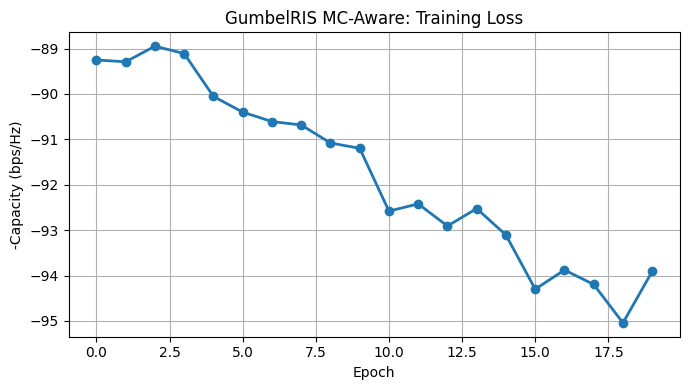

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker='o', linewidth=2)
plt.title("GumbelRIS MC-Aware: Training Loss")
plt.xlabel("Epoch")
plt.ylabel("-Capacity (bps/Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Scalability: Capacity vs RIS Size (MC-Aware)

In [17]:
def evaluate_gumbel_ris_mc(N_ris, S_mat, epochs=10):
    """
    Train + evaluate MC-aware GumbelRIS for a given N_ris.
    S_mat must be precomputed for this N_ris.
    """
    print(f"\n===== Training MC-aware for N_RIS = {N_ris} =====")

    class GumbelRIS_Dynamic(nn.Module):
        def __init__(self, tau=1.0):
            super().__init__()
            self.tau = tau
            self.conv = nn.Conv2d(6, 32, kernel_size=3, padding=1)
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc   = nn.Linear(32, N_ris * 4)

        def forward(self, x, hard=False):
            x = F.relu(self.conv(x))
            x = self.pool(x).view(x.size(0), -1)
            logits = self.fc(x).view(-1, N_ris, 4)
            y = F.gumbel_softmax(logits, tau=self.tau, hard=hard)
            return y, logits

    theta_local = torch.tensor([0, math.pi/2, math.pi, 3*math.pi/2],
                               dtype=torch.float32, device=device)

    def construct_phase_local(y):
        phi = torch.sum(y * theta_local, dim=2)
        return torch.exp(1j * phi.to(torch.float32))

    model_dyn = GumbelRIS_Dynamic().to(device)
    opt_dyn   = torch.optim.Adam(model_dyn.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model_dyn.train()
        total_loss = 0
        for x, G, H, D in train_loader:
            x, G, H, D = x.to(device), G.to(device), H.to(device), D.to(device)
            y, _ = model_dyn(x)
            gamma = construct_phase_local(y)
            loss  = -compute_capacity_mc(G, H, D, gamma, S_mat)
            opt_dyn.zero_grad()
            loss.backward()
            opt_dyn.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} | Loss {total_loss/len(train_loader):.4f}")

    model_dyn.eval()
    caps = []
    with torch.no_grad():
        for x, G, H, D in test_loader:
            x, G, H, D = x.to(device), G.to(device), H.to(device), D.to(device)
            y, _ = model_dyn(x, hard=True)
            gamma = construct_phase_local(y)
            cap   = compute_capacity_mc(G, H, D, gamma, S_mat)
            caps.append(cap.item())

    mean_cap = np.mean(caps)
    print(f"Mean Capacity for N={N_ris}: {mean_cap:.4f} bps/Hz")
    return mean_cap

In [18]:
# Precompute S matrices for each RIS size
# NOTE: For large sizes this may be slow; use caching if needed
RIS_sizes     = [4, 16, 64, 256]
avg_caps_mc   = []
avg_caps_nmc  = []

for N_ris in RIS_sizes:
    print(f"\nBuilding S matrix for N_RIS={N_ris}...")
    _, S_n = build_z_matrix(N_ris, D_ELEMENT, FREQ, array_type='UPA')
    S_n_tensor = torch.tensor(S_n, dtype=torch.complex64)

    cap_mc = evaluate_gumbel_ris_mc(N_ris, S_n_tensor, epochs=5)
    avg_caps_mc.append(cap_mc)


Building S matrix for N_RIS=4...
  lambda=0.0107m, k0=586.43, h=0.00033m, d=0.0054m
  Self-impedance Z_qq = 0.7750-1109.2910j Ohm

===== Training MC-aware for N_RIS = 4 =====


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x256 and 4x4)

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(RIS_sizes, avg_caps_mc, marker='o', linewidth=2, label='MC-Aware GumbelRIS')
plt.xscale('log', base=2)
plt.xlabel("Number of RIS Elements ($N_{RIS}$)")
plt.ylabel("Average Capacity (bps/Hz)")
plt.title("GumbelRIS MC-Aware: Capacity vs RIS Size")
plt.legend()
plt.grid(True)
plt.show()

## MC Strength Study: Capacity vs Element Spacing

Closer element spacing → stronger mutual coupling. This reproduces Fig. 10 from Zheng et al.


Spacing = lambda/2 (5.36 mm)
  lambda=0.0107m, k0=586.43, h=0.00033m, d=0.0054m
  Self-impedance Z_qq = 0.7750-1109.2910j Ohm
  Computed 5 unique separations...
  Computed 10 unique separations...
  Computed 15 unique separations...
  Computed 20 unique separations...
  Computed 25 unique separations...
  Computed 30 unique separations...
  Computed 35 unique separations...
  Computed 40 unique separations...
  Computed 45 unique separations...
  Computed 50 unique separations...
  Computed 55 unique separations...
  Computed 60 unique separations...
  Computed 65 unique separations...
  Computed 70 unique separations...
  Computed 75 unique separations...
  Computed 80 unique separations...
  Computed 85 unique separations...
  Computed 90 unique separations...
  Computed 95 unique separations...
  Computed 100 unique separations...
  Computed 105 unique separations...
  Computed 110 unique separations...
  Computed 115 unique separations...
  MC-Aware: 103.709 | No-MC: 102.781

Spac

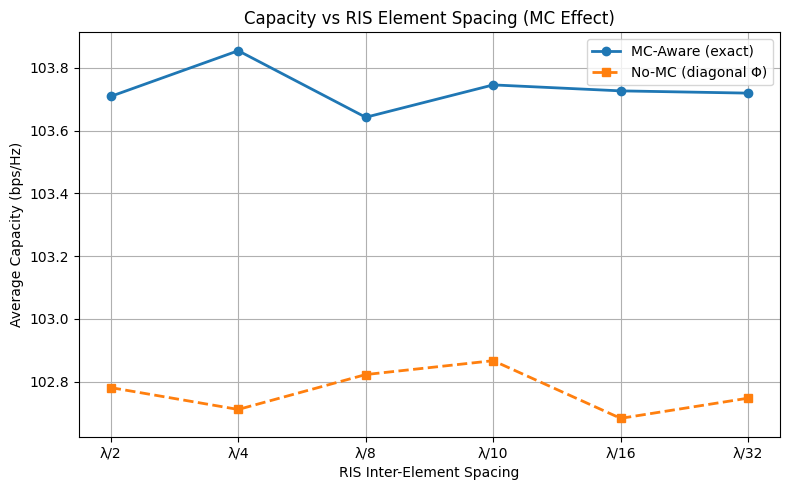

In [19]:
spacings_lambda = [1/2, 1/4, 1/8, 1/10, 1/16, 1/32]
caps_vs_spacing_mc  = []
caps_vs_spacing_nmc = []

model.eval()

for d_frac in spacings_lambda:
    d = d_frac * LAM
    print(f"\nSpacing = lambda/{int(1/d_frac)} ({d*1000:.2f} mm)")

    # Build S for this spacing
    _, S_sp = build_z_matrix(N_RIS, d, FREQ, array_type='UPA')
    S_sp_tensor = torch.tensor(S_sp, dtype=torch.complex64)

    mc_caps, nmc_caps = [], []
    with torch.no_grad():
        for x, G, H, D in test_loader:
            x, G, H, D = x.to(device), G.to(device), H.to(device), D.to(device)
            y, _ = model(x, hard=True)
            gamma = construct_phase(y)

            mc_caps.append(compute_capacity_mc(G, H, D, gamma, S_sp_tensor).item())
            nmc_caps.append(compute_capacity_no_mc(G, H, D, gamma).item())

    caps_vs_spacing_mc.append(np.mean(mc_caps))
    caps_vs_spacing_nmc.append(np.mean(nmc_caps))
    print(f"  MC-Aware: {caps_vs_spacing_mc[-1]:.3f} | No-MC: {caps_vs_spacing_nmc[-1]:.3f}")

labels = [f"λ/{int(1/d)}" for d in spacings_lambda]

plt.figure(figsize=(8, 5))
plt.plot(labels, caps_vs_spacing_mc,  marker='o', linewidth=2, label='MC-Aware (exact)')
plt.plot(labels, caps_vs_spacing_nmc, marker='s', linewidth=2, linestyle='--', label='No-MC (diagonal Φ)')
plt.xlabel("RIS Inter-Element Spacing")
plt.ylabel("Average Capacity (bps/Hz)")
plt.title("Capacity vs RIS Element Spacing (MC Effect)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Capacity vs SNR (MC-Aware)

SNR=  0 dB -> 44.7050 bps/Hz
SNR=  2 dB -> 49.6341 bps/Hz
SNR=  4 dB -> 54.5682 bps/Hz
SNR=  6 dB -> 59.9825 bps/Hz
SNR=  8 dB -> 65.3802 bps/Hz
SNR= 10 dB -> 71.2668 bps/Hz
SNR= 12 dB -> 77.2917 bps/Hz
SNR= 14 dB -> 83.5634 bps/Hz
SNR= 16 dB -> 90.0040 bps/Hz
SNR= 18 dB -> 96.8582 bps/Hz
SNR= 20 dB -> 103.5725 bps/Hz


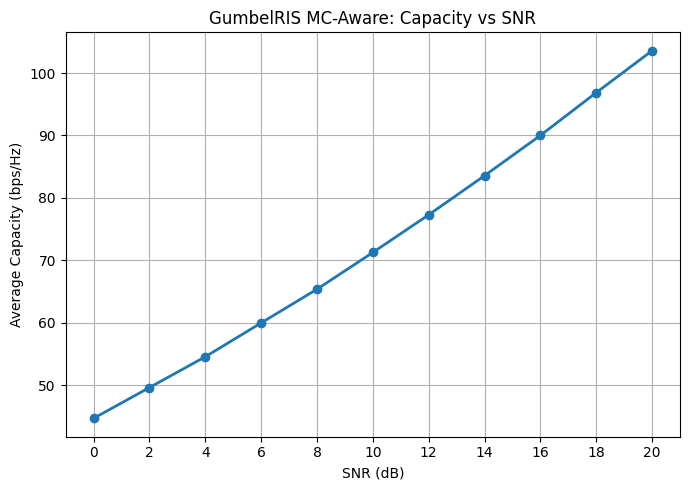

In [20]:
SNR_dB_values   = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
avg_caps_mc_snr = []

model.eval()
with torch.no_grad():
    for snr_db in SNR_dB_values:
        caps = []
        for x, G, H, D in test_loader:
            x, G, H, D = x.to(device), G.to(device), H.to(device), D.to(device)
            y, _ = model(x, hard=True)
            gamma = construct_phase(y)
            cap = compute_capacity_mc(G, H, D, gamma, S_tensor, snr_db=snr_db)
            caps.append(cap.item())
        avg_caps_mc_snr.append(np.mean(caps))
        print(f"SNR={snr_db:3d} dB -> {avg_caps_mc_snr[-1]:.4f} bps/Hz")

plt.figure(figsize=(7, 5))
plt.plot(SNR_dB_values, avg_caps_mc_snr, marker='o', linewidth=2)
plt.xlabel("SNR (dB)")
plt.ylabel("Average Capacity (bps/Hz)")
plt.title("GumbelRIS MC-Aware: Capacity vs SNR")
plt.grid(True)
plt.xticks(SNR_dB_values)
plt.tight_layout()
plt.show()